# A Practitioner's Guide to Uncertainty Quantification

Companion notebook for the STATSRO 2026 tutorial. **This time with real data**:
we predict the effective temperature $T_{\rm eff}$ of stars from their **spectra**, using high-quality labels and associated uncertainties. We will upgrade our workflow step by step, exactly
as in the slides.

**Before we start (do this now, it takes ~2 min):**

1. **Runtime → Change runtime type → T4 GPU** (free tier is fine). Everything also runs on CPU, just slower.
2. Run the *Setup* and *Data* cells below top-to-bottom while the talk continues.


## Setup

Colab ships with `torch`, `numpy`, and `matplotlib`; we only add `h5py` to read
the data file. The seed pinning makes everyone's numbers come out (nearly) the
same — "nearly", because GPU reductions are not bit-reproducible.


In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q h5py

import copy

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"running on: {device}" + ("  (enable the GPU runtime for faster training!)" if device == "cpu" else ""))

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})
BLUE, ORANGE, GRAY = "#1a5fb4", "#e66100", "#5c5c5c"


running on: cuda


## Get the data (~110 MB)

**Thirty seconds of background** (for the statisticians in the room, astronomers
may skip ahead):

- **DESI** is a survey telescope that measures a *spectrum* for millions of
  objects: the brightness of the light at each of thousands of wavelengths.
  A star's spectrum is shaped by its physics above all by its surface
  temperature $T_{\rm eff}$.
- **APOGEE** is a different survey whose instrument and pipeline measure
  stellar parameters like $T_{\rm eff}$ very precisely — *and report a
  per-star error bar*  on each measurement.
- For stars observed by **both**, we can treat APOGEE's $T_{\rm eff}$ as the
  label $y$ (with known noise $\sigma_1$) and learn to predict it from the
  DESI spectrum $x$, so that for the millions of DESI stars *without* an
  APOGEE observation, we get temperatures for free. That transfer only works
  responsibly if the predictions come with **honest uncertainties**, which is
  the whole point of today.

One HDF5 file: **10,011 stars** observed by both surveys.

| dataset | shape | meaning |
|---|---|---|
| `flux` | (10011, 1530) | DESI spectrum of each star (3630–9750 Å, rebinned ×5) |
| `ivar` | (10011, 1530) | inverse variance of each spectral pixel (known noise!) |
| `wavelength` | (1530,) | wavelength grid in Å |
| `teff` | (10011,) | APOGEE $T_{\rm eff}$ in K — our label $y$ |
| `teff_err` | (10011,) | APOGEE's per-star error $\sigma_1$ in K — **known** label noise |
| `snr` | (10011,) | median signal-to-noise of the DESI spectrum |


In [2]:
import os
import urllib.request

DATA_FILE = "desi_apogee_tutorial.h5"
DATA_URL = "https://zenodo.org/records/21400042/files/desi_apogee_tutorial.h5"  # ~110 MB, hosted on Zenodo

if not os.path.exists(DATA_FILE):
    print("downloading data ...")
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)

with h5py.File(DATA_FILE, "r") as f:
    flux = f["flux"][:]          # (n_star, n_pix)
    ivar = f["ivar"][:]          # (n_star, n_pix)
    wavelength = f["wavelength"][:]
    teff = f["teff"][:]          # K
    teff_err = f["teff_err"][:]  # K  <- APOGEE's own error bar on each label!
    snr = f["snr"][:]

n_star, n_pix = flux.shape
print(f"{n_star} stars, {n_pix} spectral pixels each")


downloading data ...
10011 stars, 1530 spectral pixels each


### Look at the data before you model it

Left: three spectra — a cool, a Sun-like, and a hot star. The **shape** of the
spectrum encodes the temperature (cool stars are red and covered in molecular
bands; hot stars are blue with strong hydrogen lines). That shape is what the
network will learn to read.

Right: the labels come **with error bars**, and those errors are strongly
**heteroskedastic** — APOGEE pins down cool stars to ~10 K but hot stars only
to ~40+ K. Keep this plot in mind for Checkpoint 2.


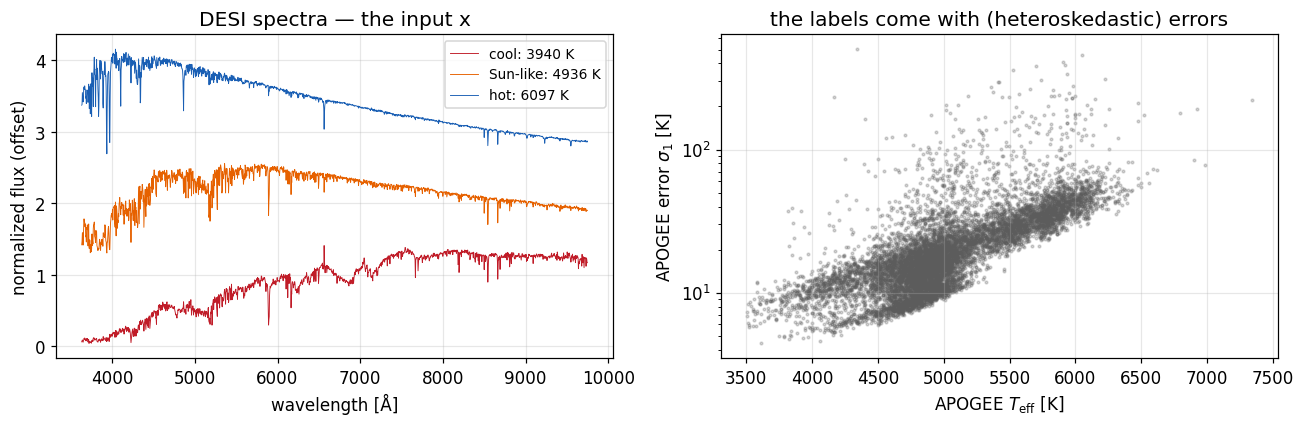

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

order = np.argsort(teff)
for pick, color, label in [
    (order[200], "#c01c28", f"cool: {teff[order[200]]:.0f} K"),
    (order[n_star // 2], ORANGE, f"Sun-like: {teff[order[n_star // 2]]:.0f} K"),
    (order[-200], BLUE, f"hot: {teff[order[-200]]:.0f} K"),
]:
    spec = flux[pick] / np.median(flux[pick])
    ax1.plot(wavelength, spec + (0 if color == "#c01c28" else (1.2 if color == ORANGE else 2.4)),
             lw=0.6, color=color, label=label)
ax1.set(xlabel="wavelength [Å]", ylabel="normalized flux (offset)", title="DESI spectra — the input x")
ax1.legend(loc="upper right", fontsize=9)

ax2.scatter(teff, teff_err, s=3, alpha=0.25, color=GRAY)
ax2.set(xlabel=r"APOGEE $T_{\rm eff}$ [K]", ylabel=r"APOGEE error $\sigma_1$ [K]",
        title=r"the labels come with (heteroskedastic) errors", yscale="log")
plt.tight_layout()


### Prepare tensors (given — run it)

Three standard, boring-but-important steps:

1. **Normalize each spectrum by its median** — the overall brightness depends on
   distance, not temperature; only the *shape* matters.
2. **Split** into train / validation / test. The validation set picks the best
   epoch; the **test set is only ever used for calibration checks** (slide:
   *pitfall 2 — never grade yourself on the training set*).
3. **Standardize** each pixel (zero mean, unit variance, using training stars
   only) and work in kilo-Kelvin — neural nets like order-one numbers.


In [4]:
# 1. shape, not brightness
med = np.median(flux, axis=1, keepdims=True)
x = flux / med

# labels in kilo-Kelvin (order-one numbers train better)
y_all = (teff / 1000.0).astype(np.float32)
sigma1_all = (teff_err / 1000.0).astype(np.float32)

# 2. train / val / test split
rng = np.random.default_rng(42)
idx = rng.permutation(n_star)
test_idx, val_idx, train_idx = idx[:2000], idx[2000:3000], idx[3000:]

# 3. per-pixel standardization, stats from the training set only
mu_pix = x[train_idx].mean(axis=0, keepdims=True)
sd_pix = x[train_idx].std(axis=0, keepdims=True) + 1e-8
x_std = ((x - mu_pix) / sd_pix).astype(np.float32)

X = torch.tensor(x_std, device=device)
Y = torch.tensor(y_all, device=device)
S1 = torch.tensor(sigma1_all, device=device)
tr = torch.tensor(train_idx, device=device)
va = torch.tensor(val_idx, device=device)
te = torch.tensor(test_idx, device=device)

print(f"train {len(tr)} | val {len(va)} | test {len(te)}")


train 7011 | val 1000 | test 2000


### The regressor + a reusable training loop (given — run it)

The same small **MLP** for the whole session: spectrum (1530 numbers) → 128 →
64 → **two outputs**. Output 0 is always the prediction $\mu$; output 1 is
spare capacity that we'll wake up at Checkpoint 3 to predict the extra scatter.
Until then it's simply ignored — so *the model never changes, only the loss does*.

`train(loss_fn)` hides the boilerplate you have seen a hundred times (or never
— either is fine): mini-batches, Adam, and two details worth knowing about:

- **σ warm-up**: the first few epochs always use plain MSE so that $\mu$ learns
  *something* before a variance head can get involved (slide: the classic NLL
  collapse).
- **early stopping**: we keep the weights from the epoch with the best
  *validation* loss, which protects everyone from over/under-training.

You will only ever write the **loss function**: it receives the model output
`out` (shape `(batch, 2)` — or `(batch, K, 2)` at Checkpoint 4), the labels
`y`, and the label errors `s1`, and returns one number.


In [5]:
def make_mlp():
    torch.manual_seed(0)  # same init for everyone, every time
    return nn.Sequential(
        nn.Linear(n_pix, 128), nn.ReLU(),
        nn.Linear(128, 64), nn.ReLU(),
        nn.Linear(64, 2),
    ).to(device)


def train(loss_fn, inputs=None, epochs=25, warmup=8, batch=512, lr=1e-3, quiet=False):
    """Train a fresh MLP with `loss_fn(out, y, s1)`; returns the best model.

    `inputs`: (X_train_like, forward) — optionally override the input tensor and
    how the model is applied to a batch (used at Checkpoint 4 for the K-sample
    losses). By default the model just runs on X.
    """
    Xin, forward = inputs if inputs is not None else (X, lambda m, xb: m(xb))
    model = make_mlp()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best_val, best_state = float("inf"), None

    for epoch in range(epochs):
        warm = epoch < warmup
        perm = torch.randperm(len(tr), device=device)
        model.train()
        for i in range(0, len(tr), batch):
            rows = tr[perm[i : i + batch]]
            opt.zero_grad()
            if warm:  # sigma warm-up: plain MSE on mu
                loss = ((model(Xin[rows])[:, 0] - Y[rows]) ** 2).mean()
            else:
                loss = loss_fn(forward(model, Xin[rows]), Y[rows], S1[rows])
                if not torch.is_tensor(loss):  # friendly guard for the checkpoints
                    raise TypeError(
                        f"your loss function returned {loss!r} instead of a tensor "
                        "— did you fill in the TODO lines?")
            loss.backward()
            opt.step()
        if not warm:  # early stopping on the validation set
            model.eval()
            with torch.no_grad():
                val_loss = loss_fn(forward(model, Xin[va]), Y[va], S1[va]).item()
            if val_loss < best_val:
                best_val, best_state = val_loss, copy.deepcopy(model.state_dict())
            if not quiet and epoch % 5 == 0:
                print(f"  epoch {epoch:3d}  val loss {val_loss:8.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


### Calibration toolbox (given — run it)

The two diagnostics from the slides, as functions. Both take **z-scores**
$z_i = (y_i - \mu_i)/\sigma_{{\rm tot},i}$ computed on the **test set**:

- `z_hist(z)` — histogram vs. the $\mathcal N(0,1)$ it should follow,
- `pp_plot(z)` — empirical coverage of the central-$p$ interval vs. $p$
  (calibrated ⇒ on the diagonal).


In [6]:
from scipy import stats as sstats


def z_hist(z, ax=None, label=None):
    ax = ax or plt.gca()
    ax.hist(np.clip(z, -6, 6), bins=np.linspace(-6, 6, 41), density=True, color=GRAY, alpha=0.6, label=label)
    zz = np.linspace(-6, 6, 200)
    ax.plot(zz, sstats.norm.pdf(zz), "--", color=ORANGE, lw=2, label=r"$\mathcal{N}(0,1)$")
    ax.set(xlabel="z", ylabel="density")
    ax.legend(fontsize=9)
    ax.set_title(f"z spread = {np.std(z):.2f}  (calibrated ⇒ 1.0)", fontsize=10)


def pp_plot(z_dict, ax=None):
    """z_dict: {label: z_array}. Plots one P-P curve per entry."""
    ax = ax or plt.gca()
    ps = np.linspace(0.5, 0.99, 25)
    ax.plot([0.5, 1], [0.5, 1], "--", color="gray", lw=1)
    for label, z in z_dict.items():
        zt = sstats.norm.ppf((1 + ps) / 2)
        emp = [(np.abs(z) <= t).mean() for t in zt]
        ax.plot(ps, emp, lw=2.5, label=label)
    ax.set(xlabel="stated probability p", ylabel="empirical coverage")
    ax.legend(fontsize=9)


def evaluate(model, name, total_var_fn=None, inputs=None):
    """Predict on the test set; return (mu, sigma_tot, z) in kilo-Kelvin.

    total_var_fn(out, s1) -> total variance. Default: sigma1^2 only
    (i.e. 'my only uncertainty is the label error').
    """
    Xin, forward = inputs if inputs is not None else (X, lambda m, xb: m(xb))
    model.eval()
    with torch.no_grad():
        out = forward(model, Xin[te])
        mu = out[..., 0]
        var = total_var_fn(out, S1[te]) if total_var_fn else S1[te] ** 2
        mu, var = mu.cpu().numpy(), var.cpu().numpy()
    resid = mu - y_all[test_idx]
    z = resid / np.sqrt(var)
    rmse = 1000 * resid.std()
    print(f"{name:18s} test RMSE {rmse:6.1f} K | z spread {z.std():5.2f} | median sigma_tot {1000 * np.median(np.sqrt(var)):5.0f} K")
    return mu, np.sqrt(var), z


---
## ✏️ Checkpoint 1 — the standard recipe (MSE)

*Slides: "The Standard Recipe for Fitting" / "Maximizing the Likelihood, in Disguise".*

Baseline first: predict $\mu = f_\theta(\text{spectrum})$ by minimizing the
**mean squared error**. Remember what the slides said this secretly assumes —
Gaussian noise with one constant σ, all of it on $y$.

Fill in the loss. `out[:, 0]` is the prediction $\mu$; ignore `out[:, 1]` and
`s1` for now.


In [7]:
def mse_loss(out, y, s1):
    mu = out[:, 0]
    return ((mu - y) ** 2).mean()


model_mse = train(mse_loss)
mu_mse, sig_mse, z_mse = evaluate(model_mse, "MSE", total_var_fn=None)

  epoch  10  val loss   0.3691
  epoch  15  val loss   0.2142
  epoch  20  val loss   0.1579
MSE                test RMSE  348.9 K | z spread 19.87 | median sigma_tot    18 K


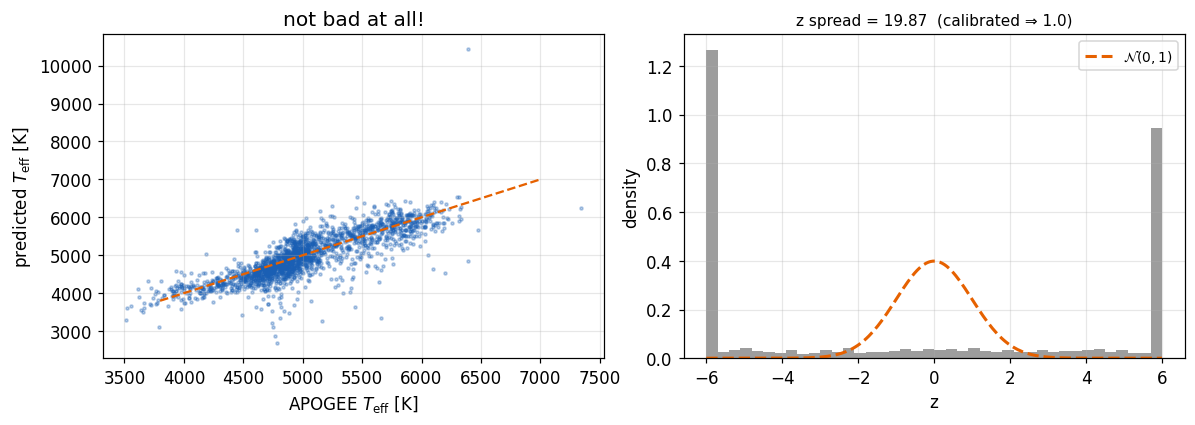

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.scatter(y_all[test_idx] * 1000, mu_mse * 1000, s=4, alpha=0.3, color=BLUE)
lims = [3800, 7000]
ax1.plot(lims, lims, "--", color=ORANGE)
ax1.set(xlabel=r"APOGEE $T_{\rm eff}$ [K]", ylabel=r"predicted $T_{\rm eff}$ [K]", title="not bad at all!")
z_hist(z_mse, ax=ax2)
plt.tight_layout()


**What just happened?** The predictions track the truth to a few hundred K —
a perfectly respectable model. But look at the z-histogram: if the only
uncertainty were the APOGEE label error $\sigma_1 \sim 15\,$K, the z's should
be $\mathcal N(0,1)$. They are **~20× too wide**. Quoting $\sigma_1$ as your
error bar here would be *catastrophically overconfident* — this is the slide
"The Problem: Scatter Beyond the Error Bars", live.


---
## ✏️ Checkpoint 2 — the labels have (different) error bars: χ²

*Slide: "When σ Varies: Weighted MSE = χ²".*

The data-tour plot showed $\sigma_1$ varies by a factor of ~5 across the sample
— and we *know* each star's value. The derivation on the slide says: redo
maximum likelihood with per-point σ and MSE becomes **weighted MSE**, χ².

Fill in the χ² loss (weight each squared residual by $1/\sigma_1^2$).


In [9]:
def chi2_loss(out, y, s1):
    mu = out[:, 0]
    return (((mu - y) / s1) ** 2).mean()


model_chi2 = train(chi2_loss)
mu_chi2, sig_chi2, z_chi2 = evaluate(model_chi2, "chi^2", total_var_fn=None)

  epoch  10  val loss 1658.1993
  epoch  15  val loss 808.8850
  epoch  20  val loss 635.2839
chi^2              test RMSE  340.0 K | z spread 17.85 | median sigma_tot    18 K


**What changed — and what didn't.** The fit now pays most attention to the
precisely-labeled stars (weights up to ~25× larger for a cool star at 10 K
than a hot star at 50 K). But the z spread is *still* ~20: no amount of
re-weighting can fix error bars that simply **underexplain the scatter**. The
missing variance is real — the model can't extract every Kelvin from a DESI
spectrum — and nothing in our loss lets it *say* so. That is exactly what the
next checkpoint adds.


---
## ✏️ Checkpoint 3 — learn the extra scatter σ₂(x)

*Slides: "The Problem: Scatter Beyond the Error Bars" / "Learning the Extra Scatter".*

Wake up the second output. The model now predicts both $\mu(x)$ **and** the
*extra* scatter $\sigma_2(x)$ on top of the known label error $\sigma_1$.
Independent Gaussians ⇒ **variances add**:

$$\sigma_{\rm tot}^2 = \sigma_1^2 + \sigma_2^2, \qquad
\mathcal{L} = \frac{(y-\mu)^2}{2\,\sigma_{\rm tot}^2} + \tfrac12 \log \sigma_{\rm tot}^2 .$$

`softplus(out[:, 1])` is $\sigma_2^2$ (softplus keeps a variance positive).
Fill in the total variance and the NLL — this is the 2-line diff on the slide.


In [10]:
def nll_loss(out, y, s1):
    mu, s2_raw = out[..., 0], out[..., 1]
    var = s1 ** 2 + F.softplus(s2_raw)
    return (0.5 * ((y - mu) ** 2 / var + torch.log(var))).mean()


def total_var(out, s1):
    return s1 ** 2 + F.softplus(out[..., 1])


model_nll = train(nll_loss, epochs=30)
mu_nll, sig_nll, z_nll = evaluate(model_nll, "NLL + sigma2 head", total_var_fn=total_var)




  epoch  10  val loss   0.2746
  epoch  15  val loss  -0.2486
  epoch  20  val loss  -0.3890
  epoch  25  val loss  -0.3017
NLL + sigma2 head  test RMSE  390.0 K | z spread  1.02 | median sigma_tot   303 K


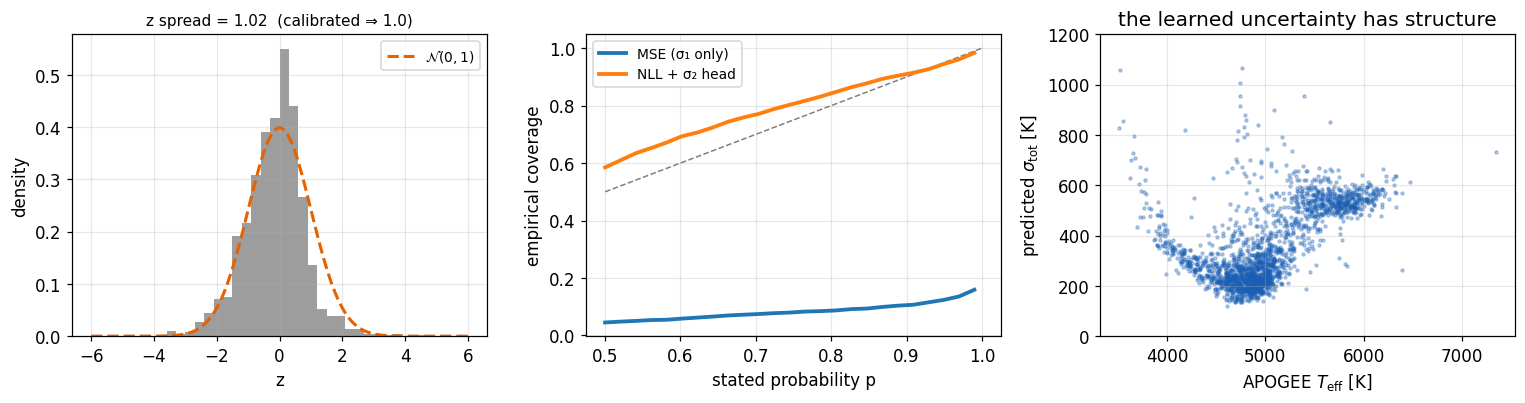

In [12]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 3.8))
z_hist(z_nll, ax=ax1)
pp_plot({"MSE (σ₁ only)": z_mse, "NLL + σ₂ head": z_nll}, ax=ax2)
ax3.scatter(y_all[test_idx] * 1000, sig_nll * 1000, s=4, alpha=0.3, color=BLUE)
ax3.set(xlabel=r"APOGEE $T_{\rm eff}$ [K]", ylabel=r"predicted $\sigma_{\rm tot}$ [K]",
        title="the learned uncertainty has structure", ylim=(0, 1200))
plt.tight_layout()


**Calibrated.** Two lines of loss took the z spread from ~20 to ~1 and put the
P–P curve on the diagonal. And the right-hand panel shows σ₂ isn't one number —
the model has learned *which stars* it can and cannot predict well (compare the
shape to the APOGEE-error plot from the data tour). Your error bars now mean
what they claim. **This is the single highest-value change in the tutorial.**


---
## ✏️ Checkpoint 4 — the spectra are noisy too: marginalize, don't average

*Slides: "Errors on x: the Tempting Fix" / "The Right Way: Marginalize" / "The Payoff".*

So far we treated the spectrum as perfectly known — all error on $y$. But DESI
gives us `ivar`: we **know the noise of every pixel**. Our spectra are so deep
(median per-pixel S/N ≈ 300) that it genuinely doesn't matter — so, to see the
physics of the method, we simulate a **shallower survey**: add noise of known
size $\sigma_x$ to every standardized pixel. Now `x` is noisy *and we know by
how much* — exactly the setting of Act 6.

Three ways to train on noisy inputs (all use the σ₂-head NLL from Checkpoint 3):

- **ignore** — pretend x is exact (given),
- **naive** — draw K noisy copies $\tilde x_k \sim \mathcal N(x, \sigma_x^2)$
  and **average the K losses** (given — the tempting fix),
- **logsumexp** — same K copies, but $-\log$ of the **average likelihood**
  (you write this line):

$$\mathcal{L} = -\operatorname{logsumexp}_k(-{\rm nll}_k) + \log K .$$


In [15]:
# --- a shallower survey with KNOWN per-pixel noise (given — run it) ----------
SIGMA_X = 0.5  # in standardized-pixel units; known, like ivar would be
rng_noise = np.random.default_rng(1)
Xnoisy = X + torch.tensor(
    rng_noise.standard_normal(x_std.shape).astype(np.float32), device=device) * SIGMA_X

K = 1  # samples per star during training


def jitter(xb, k=K):
    """Draw k fresh noisy realizations around each (already noisy) input."""
    return xb.unsqueeze(1) + torch.randn(xb.shape[0], k, xb.shape[1], device=device) * SIGMA_X


def nll_pointwise(out, y, s1):
    mu, s2_raw = out[..., 0], out[..., 1]
    var = s1 ** 2 + F.softplus(s2_raw)
    return 0.5 * ((y - mu) ** 2 / var + torch.log(var))


# method 1 — IGNORE the x-noise (given)
def ignore_loss(out, y, s1):
    return nll_pointwise(out, y, s1).mean()


# method 2 — NAIVE sampling: average the losses (given; note the .mean over K)
def naive_loss(out_k, y, s1):          # out_k: (batch, K, 2)
    nll_k = nll_pointwise(out_k, y.unsqueeze(1), s1.unsqueeze(1))  # (batch, K)
    return nll_k.mean()


# method 3 — MARGINALIZE with logsumexp: -log of the AVERAGE LIKELIHOOD
def logsumexp_loss(out_k, y, s1):      # out_k: (batch, K, 2)
    nll_k = nll_pointwise(out_k, y.unsqueeze(1), s1.unsqueeze(1))  # (batch, K)
    return (-torch.logsumexp(-nll_k, dim=1) + np.log(K)).mean()


single = (Xnoisy, lambda m, xb: m(xb))
sampled = (Xnoisy, lambda m, xb: m(jitter(xb)))

model_ignore = train(ignore_loss, inputs=single, epochs=40, quiet=True)
model_naive = train(naive_loss, inputs=sampled, epochs=40, quiet=True)
model_lse = train(logsumexp_loss, inputs=sampled, epochs=40, quiet=True)
print("all three trained.")

all three trained.


**Predicting with a noisy input** uses the *same* marginalization (this is the
formula on the "Marginalize" slide — the loss *is* the negative log of this
predictive): draw K realizations of the input, and combine the K Gaussians —
means average, and the **law of total variance** adds the spread *between*
samples to the variance *within* them. Given below; run and compare.


ignore x-noise     test RMSE  678.5 K | z spread  1.26 | median sigma_tot   531 K
naive sampling     test RMSE  535.6 K | z spread  0.90 | median sigma_tot   612 K
logsumexp          test RMSE  535.1 K | z spread  1.19 | median sigma_tot   469 K


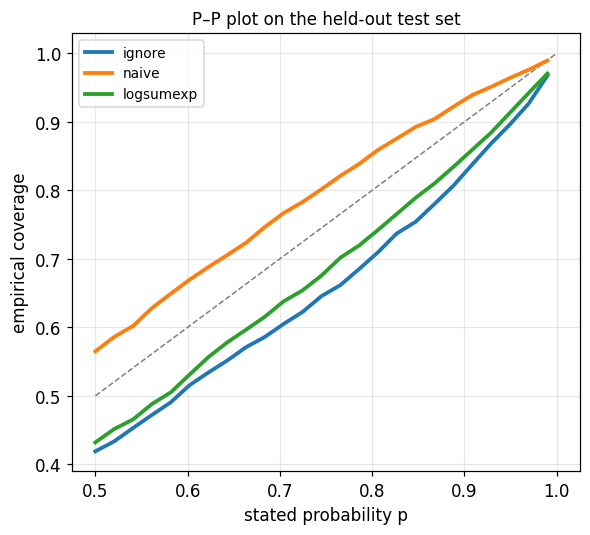

In [14]:
def marginal_forward(m, xb, k=32):
    out_k = m(jitter(xb, k))                       # (n, k, 2)
    mu_k = out_k[..., 0]
    var_k = F.softplus(out_k[..., 1])              # sigma2^2 per sample
    mu = mu_k.mean(dim=1)
    var2 = (var_k + mu_k ** 2).mean(dim=1) - mu ** 2   # law of total variance
    # repack as (n, 2)-like tuple for evaluate(): mu and raw var channel
    return torch.stack([mu, var2], dim=-1)


def total_var_marginal(out, s1):
    return s1 ** 2 + out[..., 1]   # out[...,1] already IS the sigma2^2 mixture


_, _, z_ignore = evaluate(model_ignore, "ignore x-noise", total_var_fn=total_var, inputs=single)
_, _, z_naive = evaluate(model_naive, "naive sampling", total_var_fn=total_var_marginal,
                         inputs=(Xnoisy, marginal_forward))
_, _, z_lse = evaluate(model_lse, "logsumexp", total_var_fn=total_var_marginal,
                       inputs=(Xnoisy, marginal_forward))

fig, ax = plt.subplots(figsize=(5.5, 5))
pp_plot({"ignore": z_ignore, "naive": z_naive, "logsumexp": z_lse}, ax=ax)
ax.set_title("P–P plot on the held-out test set", fontsize=11)
plt.tight_layout()


**Reading the result** (numbers vary a little run to run):

| method | what it does | typical outcome |
|---|---|---|
| ignore | pretends x is exact | **overconfident** — z spread > 1, curve below diagonal |
| naive | averages the K *losses* | **fattest intervals** — pays for double-counting the noise |
| logsumexp | −log of the average *likelihood* | **best RMSE, tightest calibrated intervals** |

The one-character-feeling difference — *where the log sits relative to the
average* — is Jensen's inequality doing real damage or real work.


---
## The cheat sheet, in code you now own

| Assumption | The minimal fix | You wrote it at |
|---|---|---|
| Gaussian errors | Gaussian NLL (or swap the likelihood) | Checkpoint 1 → 3 |
| Constant σ | weight by $1/\sigma_1^2$ (χ²) + z-score check | Checkpoint 2 |
| σ₁ tells the whole story | learn σ₂(x) with a second output | Checkpoint 3 |
| Error only on y | marginalize x with `logsumexp` | Checkpoint 4 |

**Try at home**

- Predict $\log g$ or [Fe/H] instead — same file, columns are in the full
  catalogue; does σ₂ behave differently?
- Split the P–P plot by $T_{\rm eff}$ bins (slide: *aggregate ≠ conditional*).
  Is the model calibrated for the hot stars alone?
- Use the *real* per-pixel noise from `ivar` instead of our synthetic σ_x.
- Epistemic uncertainty (what we did *not* cover): train a small deep ensemble
  (5 seeds) and compare the spread of μ across members to σ₂.
